In [1]:
!pip install face_recognition opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import face_recognition
import os
import pickle

known_encodings = []
known_names = []

dataset_path = "/content/drive/MyDrive/Face detection/dataset_fc"

for person_name in os.listdir(dataset_path):

    person_folder = os.path.join(dataset_path, person_name)

    if not os.path.isdir(person_folder):
        continue

    print(f"Processing {person_name}...")

    for image_name in os.listdir(person_folder):

        image_path = os.path.join(person_folder, image_name)

        try:
            image = face_recognition.load_image_file(image_path)

            encodings = face_recognition.face_encodings(image)

            if len(encodings) > 0:
                known_encodings.append(encodings[0])
                known_names.append(person_name)

        except Exception as e:
            print("Error:", image_name)

print("Total Faces Trained:", len(known_names))

with open("face_model.pkl", "wb") as f:
    pickle.dump(
        {
            "encodings": known_encodings,
            "names": known_names
        },
        f
    )

print("Training Complete")

Processing person_1...
Processing person_2...
Total Faces Trained: 9
Training Complete


<IPython.core.display.Javascript object>

Photo Saved: captured.jpg
Best Distance: 0.42807497107043474


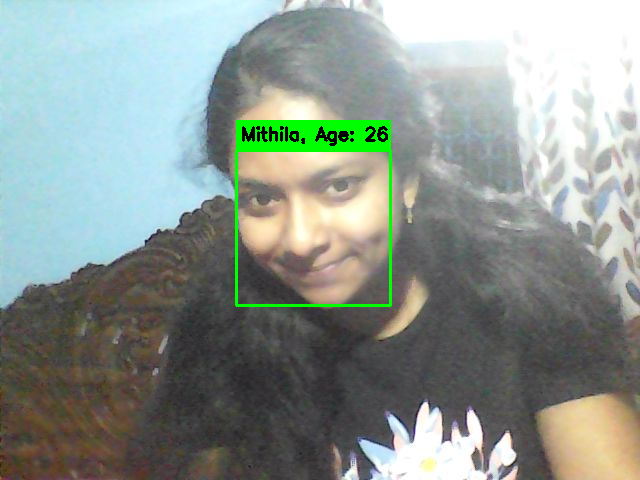

In [7]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

import pickle
import face_recognition
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =========================
# TAKE PHOTO
# =========================
def take_photo(filename='captured.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');

      const capture = document.createElement('button');
      capture.textContent = 'Capture';

      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video:true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


photo = take_photo()
print("Photo Saved:", photo)

# =========================
# PERSON INFO
# =========================
person_info = {
    "person_1": {
        "name": "Mithila",
        "age": 26
    },
    "person_2": {
        "name": "Rokeya Khatun",
        "age": 45
    }
}

# =========================
# LOAD MODEL
# =========================
with open("face_model.pkl", "rb") as f:
    data = pickle.load(f)

known_encodings = data["encodings"]
known_names = data["names"]

# =========================
# LOAD IMAGE
# =========================
image = face_recognition.load_image_file("captured.jpg")

face_locations = face_recognition.face_locations(image)
face_encodings = face_recognition.face_encodings(image, face_locations)

image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# =========================
# RECOGNITION
# =========================
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    name = "Unknown"

    if len(known_encodings) > 0:

        # calculate distances
        distances = face_recognition.face_distance(known_encodings, face_encoding)

        best_match_index = np.argmin(distances)
        best_distance = distances[best_match_index]

        print("Best Distance:", best_distance)

        # ✅ BETTER THRESHOLD (important fix)
        if best_distance < 0.55:
            name = known_names[best_match_index]

    # =========================
    # LABEL
    # =========================
    if name in person_info:

        label = f"{person_info[name]['name']}, Age: {person_info[name]['age']}"

    else:
        label = "Unknown"

    # =========================
    # DRAW BOX
    # =========================
    cv2.rectangle(image, (left, top), (right, bottom), (0, 255, 0), 2)

    cv2.rectangle(image, (left, top - 30), (right, top), (0, 255, 0), cv2.FILLED)

    cv2.putText(image, label, (left + 5, top - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

cv2_imshow(image)